   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
1       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
2       0  ...       0.0       0.0       0.0      30.0      43.0       0.0   
3       0  ...       3.0       0.0       0.0       0.0       0.0       1.0   
4       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   

   pixel781  pixel782  pixel783  pixel784  
0       0.0       0.0       0.

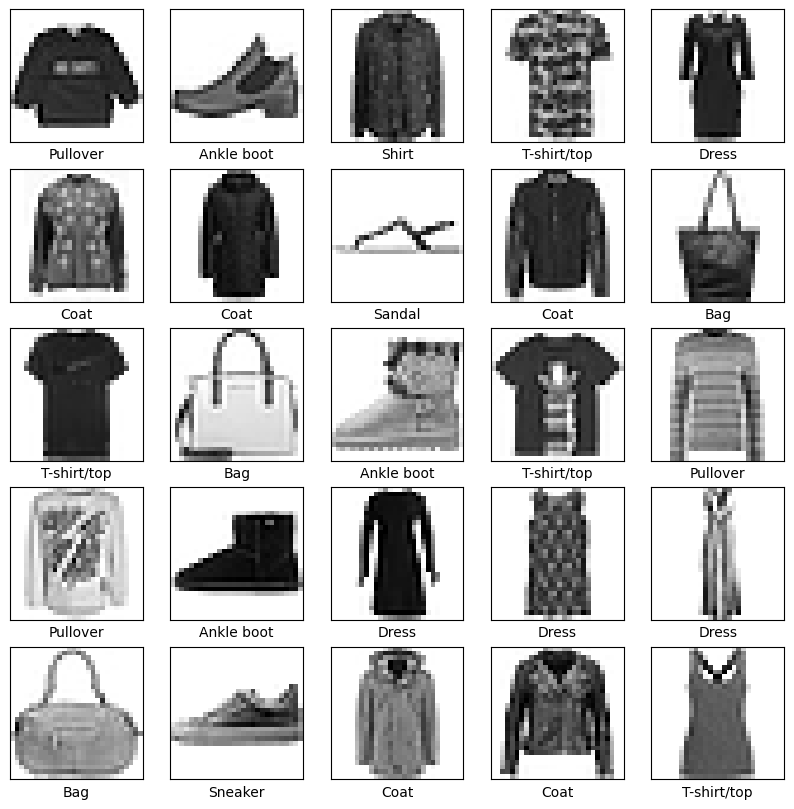

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.6878 - loss: nan
Epoch 2/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.0994 - loss: nan
Epoch 3/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.0994 - loss: nan
Epoch 4/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.0994 - loss: nan
Epoch 5/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.0994 - loss: nan
313/313 - 3s - 11ms/step - accuracy: 0.1000 - loss: nan

Test Accuracy : 10.000000149011612
Test Loss     : nan
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


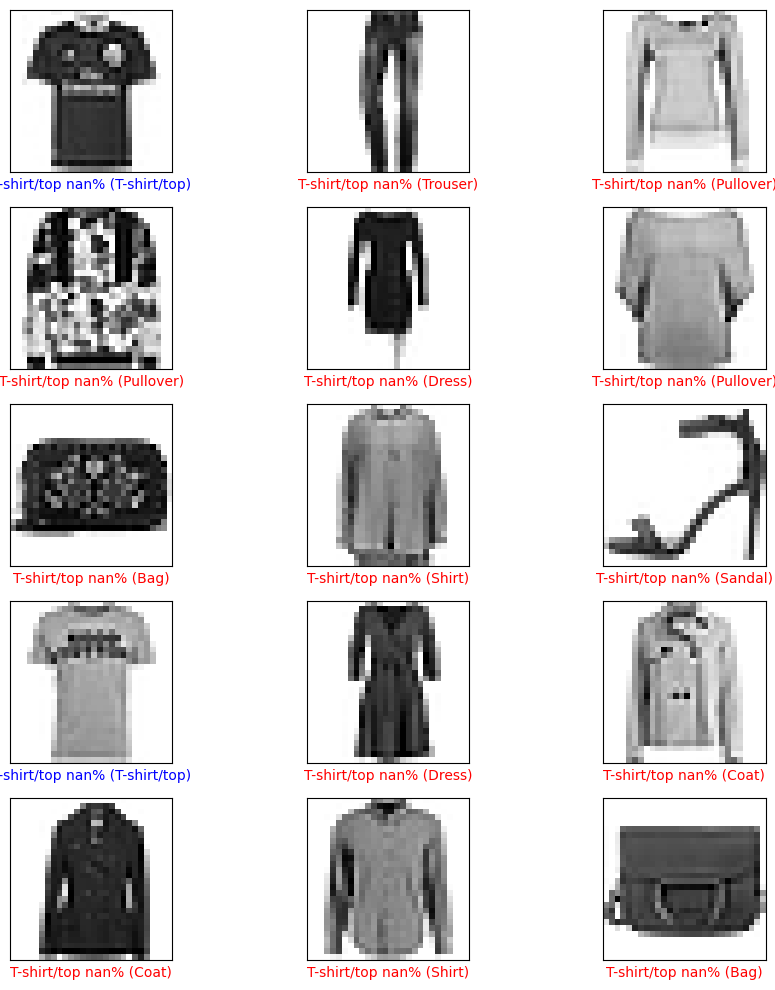

In [2]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# ==============================
# LOAD CSV DATASET
# ==============================
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

print(train_df.head())

# ==============================
# SPLIT FEATURES & LABELS
# ==============================
train_labels = train_df.iloc[:, 0].values
train_images = train_df.iloc[:, 1:].values

test_labels = test_df.iloc[:, 0].values
test_images = test_df.iloc[:, 1:].values

# ==============================
# NORMALIZATION
# ==============================
train_labels = train_labels.astype('int')
test_labels = test_labels.astype('int')

train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0
# ==============================
# RESHAPE FOR CNN
# ==============================
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

print("Train Shape:", train_images.shape)
print("Test Shape :", test_images.shape)

# ==============================
# CLASS NAMES
# ==============================
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# ==============================
# VISUALIZE SAMPLE IMAGES
# ==============================
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(train_images[i].reshape(28,28), cmap=plt.cm.binary)

    plt.xlabel(class_names[train_labels[i]])

plt.show()

# ==============================
# CNN MODEL
# ==============================
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

# ==============================
# MODEL SUMMARY
# ==============================
model.summary()

# ==============================
# COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# TRAIN MODEL
# ==============================
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    verbose=1
)

# ==============================
# EVALUATE MODEL
# ==============================
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=2
)

print("\n==============================")
print("Test Accuracy :", test_acc * 100)
print("Test Loss     :", test_loss)
print("==============================")

# ==============================
# PREDICTIONS
# ==============================
predictions = model.predict(test_images)

# ==============================
# PLOT FUNCTION
# ==============================
def plot_image(i, predictions_array, true_label, img):

    true_label = true_label[i]
    img = img[i].reshape(28,28)

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)

    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(
        "{} {:2.0f}% ({})".format(
            class_names[predicted_label],
            100*np.max(predictions_array),
            class_names[true_label]
        ),
        color=color
    )

# ==============================
# VISUALIZE PREDICTIONS
# ==============================
rows = 5
cols = 3

plt.figure(figsize=(10,10))

for i in range(rows * cols):

    plt.subplot(rows, cols, i+1)

    plot_image(
        i,
        predictions[i],
        test_labels,
        test_images
    )

plt.tight_layout()
plt.show()